In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
data_path = '../optimized_results/ncdg'

models = ['original', 'extendedBase', 'extendedAdv', 'extendedMLP']

In [3]:
order = [f'pred_{i+1}' for i in range(50)]

In [7]:
df

,interaction_num,mrr,ndcg,count
0,1,0.009133,0.027796,26418.0
1,2,0.015640,0.044332,14960.0
2,3,0.021138,0.057923,10204.0
3,4,0.026347,0.070433,7685.0
4,5,0.031549,0.082281,6062.0
...,...,...,...,...
242,243,0.000000,0.000000,1.0
243,244,0.000000,0.000000,1.0
244,245,0.000000,0.000000,1.0
245,246,0.000000,0.000000,1.0


C:\Users\dodok\AppData\Local\Temp\ipykernel_19320\3629109632.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\dodok\AppData\Local\Temp\ipykernel_19320\3629109632.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\dodok\AppData\Local\Temp\ipykernel_19320\3629109632.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping col

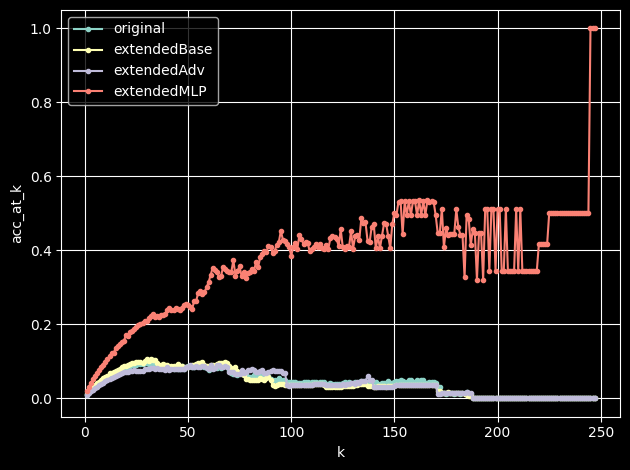

In [8]:


plt.figure()

for m in models:
    df_list = []
    dir_path = f'{data_path}/{m}'
    for f in os.listdir(dir_path):
        path = os.path.join(dir_path, f)
        if path.endswith('.csv'):
            df = pd.read_csv(path)
            df['split'] = f
            df_list.append(df)

    df = pd.concat(df_list, ignore_index=True)

    df = (
        df.groupby("interaction_num")
        .apply(lambda g: pd.Series({
            "mrr": (g["mrr"] * g["count"]).sum() / g["count"].sum(),
            "ndcg": (g["ndcg"] * g["count"]).sum() / g["count"].sum(),
            "count": g["count"].sum()
        }))
        .reset_index()
    )


    line, = plt.plot(df['interaction_num'], df['mrr'], label=f'{m}', marker='o', markersize=3)


    # plt.grid()




plt.xlabel("k")
plt.ylabel("acc_at_k")
plt.legend()
plt.tight_layout()
plt.grid()
plt.ylim([-0.05,1.05])
plt.show()


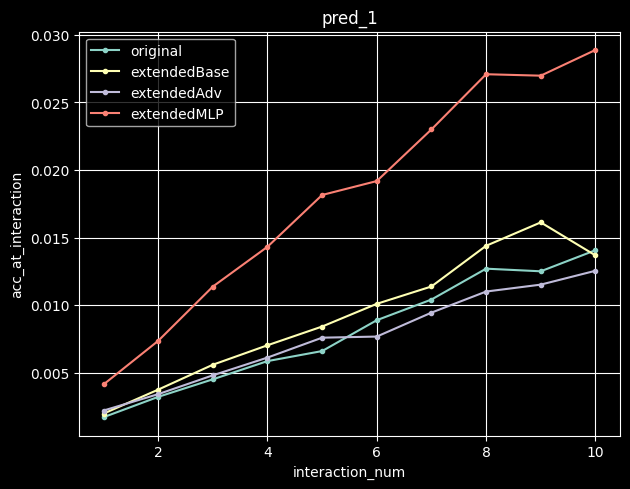

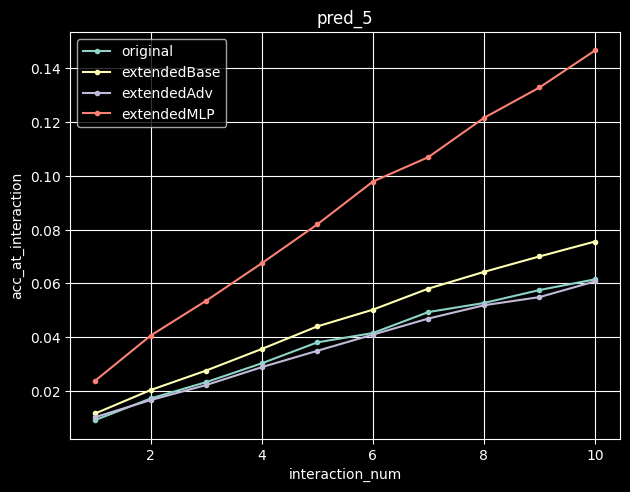

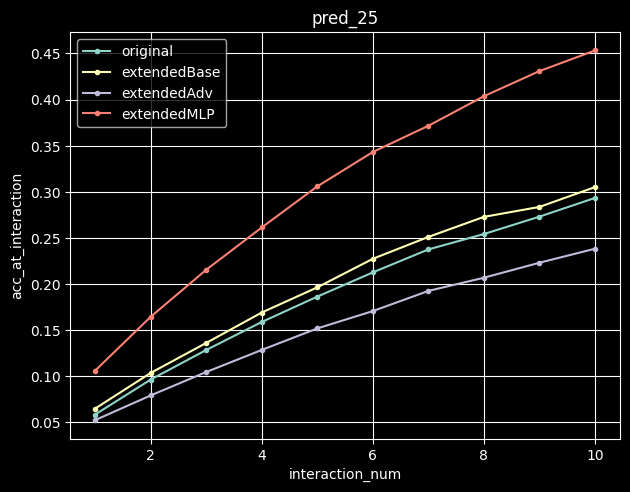

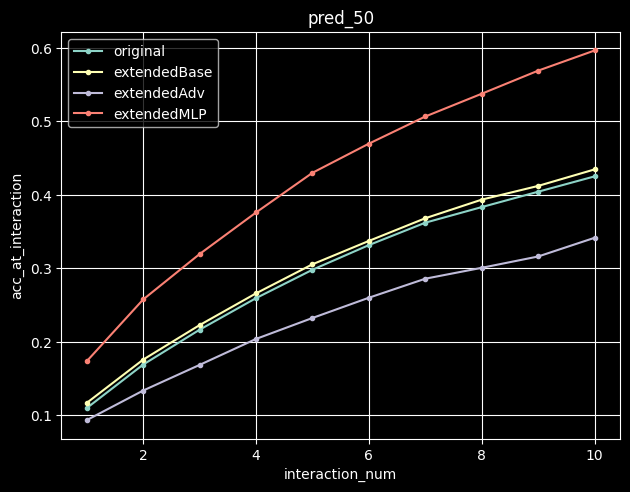

In [5]:
wanted_cols = [1, 5, 25, 50]
# wanted_cols = [1]
max_interaction = 10
models = ['original', 'extendedBase', 'extendedAdv', 'extendedMLP']
# models = ['original', 'extended']


for wanted_col in wanted_cols:
    plt.figure()
    for m in models:
        df_list = []
        dir_path = f'{data_path}/{m}'
        for f in os.listdir(dir_path):
            path = os.path.join(dir_path, f)
            if path.endswith('.csv'):
                df = pd.read_csv(path)
                df['split'] = f
                df_list.append(df)

        df = pd.concat(df_list, ignore_index=True)

        df["correct"] = (df["accuracy"] * df["count"]).round().astype(int)

        df = df[df['col_name'] == f'pred_{wanted_col}']

        df = df.groupby(['interaction_num', 'split'])[['count', 'correct']].sum()
        df['acc'] = df['correct'] / df['count']

        df = df.groupby('interaction_num')['acc'].agg(['mean', 'std'])

        df['inter_num'] = [x for x in df.index.values]

        df = df.sort_values('inter_num')

        df = df[:max_interaction]

        line, = plt.plot(df['inter_num'], df['mean'], label=f'{m}', marker='o', markersize=3)


        plt.fill_between(
            df['inter_num'],
            df['mean'] - 1.96 * df['std'],
            df['mean'] + 1.96 * df['std'],
            alpha=0.1,
            color=line.get_color()
        )
        # plt.grid()


    plt.xlabel("interaction_num")
    plt.ylabel("acc_at_interaction")
    plt.legend()
    plt.tight_layout()
    plt.grid()
    # plt.ylim([-0.02,0.22])
    plt.title(f'pred_{wanted_col}')
    plt.show()

In [9]:
wanted_cols = [1, 5, 25, 50]
# wanted_cols = [1]
max_interaction = 100
models = ['original', 'extendedBase', 'extendedAdv', 'extendedMLP']
# models = ['original', 'extended']


for wanted_col in wanted_cols:
    plt.figure()
    for m in models:
        df_list = []
        dir_path = f'{data_path}/{m}'
        for f in os.listdir(dir_path):
            path = os.path.join(dir_path, f)
            if path.endswith('.csv'):
                df = pd.read_csv(path)
                df['split'] = f
                df_list.append(df)


        df = pd.concat(df_list, ignore_index=True)

        df["correct"] = (df["accuracy"] * df["count"]).round().astype(int)

        df = df[df['col_name'] == f'pred_{wanted_col}']

        df = df.groupby(['interaction_num', 'split'])[['count', 'correct']].sum()
        df['acc'] = df['correct'] / df['count']

        df = df.groupby('interaction_num')['acc'].agg(['mean', 'std'])

        df['inter_num'] = [x for x in df.index.values]

        df = df.sort_values('inter_num')

        df = df[:max_interaction]

        line, = plt.plot(df['inter_num'], df['mean'], label=f'{m}', marker='o', markersize=3)


        plt.fill_between(
            df['inter_num'],
            df['mean'] - 1.96 * df['std'],
            df['mean'] + 1.96 * df['std'],
            alpha=0.1,
            color=line.get_color()
        )
        # plt.grid()


    plt.xlabel("interaction_num")
    plt.ylabel("acc_at_interaction")
    plt.legend()
    plt.tight_layout()
    plt.grid()
    # plt.ylim([-0.02,0.22])
    plt.title(f'pred_{wanted_col}')
    plt.show()

KeyError: 'accuracy'

<Figure size 640x480 with 0 Axes>

In [7]:
full_df = pd.read_parquet('../sorted_data.parquet')

In [8]:
df = full_df.groupby(['user_id', 'track_id']).count()

In [9]:
values = df["ts"].values

max_n = values.max()

interaction_counts = pd.Series(
    np.sum(values[:, None] >= np.arange(1, max_n + 1), axis=0),
    index=np.arange(1, max_n + 1)
)

In [10]:
interaction_counts[:50]

1     4892757
2     2642812
3     1719906
4     1225006
5      921462
6      722202
7      582977
8      480781
9      403086
10     342494
11     293547
12     253304
13     219806
14     191838
15     168008
16     148079
17     130958
18     116239
19     103398
20      92364
21      82566
22      74014
23      66580
24      60013
25      54268
26      49182
27      44634
28      40675
29      37201
30      33973
31      31090
32      28542
33      26222
34      24165
35      22284
36      20654
37      19083
38      17648
39      16304
40      15123
41      13985
42      12978
43      12052
44      11249
45      10518
46       9824
47       9181
48       8593
49       8038
50       7521
dtype: int64

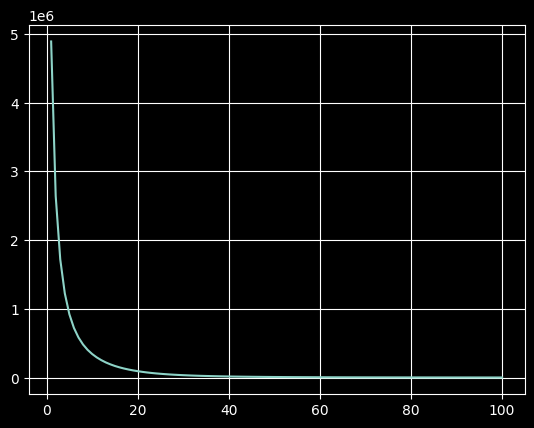

In [11]:
plt.plot(interaction_counts[:100])
# plt.yscale('log')
plt.grid()